# Text2Preset MVP: LLM-initialized Text2FX

## Setup: Install Dependencies

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch, torchvision
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as pl
from pathlib import Path
from IPython.display import Audio, display, HTML, clear_output
import ipywidgets as widgets
import json
import dasp_pytorch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")

✓ Using device: cpu


## Core Functions: Inline Implementation

In [3]:
from embeddings.clap import CLAPWrapper

In [ ]:
from effects.fxchain import FXChainFactory
FXChainFactory.create_fx_chain()

✓ FX chain created: 49 parameters


In [10]:
# ========== Text2FX Refinement ==========

def directional_loss(audio_anchor, audio_effected, text_anchor, text_target):
    """Compute directional loss in CLAP embedding space."""
    # Ensure all inputs are torch tensors
    if not isinstance(audio_anchor, torch.Tensor):
        audio_anchor = torch.from_numpy(audio_anchor)
    if not isinstance(audio_effected, torch.Tensor):
        audio_effected = torch.from_numpy(audio_effected)
    if not isinstance(text_anchor, torch.Tensor):
        text_anchor = torch.from_numpy(text_anchor)
    if not isinstance(text_target, torch.Tensor):
        text_target = torch.from_numpy(text_target)

    audio_dir = F.normalize(audio_effected - audio_anchor, dim=-1)
    text_dir = F.normalize(text_target - text_anchor, dim=-1)
    return (1 - F.cosine_similarity(audio_dir, text_dir, dim=-1)).mean()

def refine_with_directional_loss(
    audio, fx_chain, initial_params, text_anchor, text_target,
    clap_model, n_iterations=100, lr=0.01, device=None,
    snapshot_interval=None
):
    """Refine parameters using gradient descent in CLAP space.

    If snapshot_interval is set, saves FX params every N iterations
    for on-demand audio rendering via slider.
    """
    if device is None:
        device = audio.device

    # Shorten audio for faster CLAP processing (use first 5 seconds)
    max_clap_samples = 5 * 44100
    if audio.shape[-1] > max_clap_samples:
        audio_short = audio[..., :max_clap_samples]
        print(f"⚡ Using shortened audio for CLAP: {audio_short.shape[-1]/44100:.1f}s instead of {audio.shape[-1]/44100:.1f}s")
    else:
        audio_short = audio

    # Setup - ensure initial_params is on correct device and requires grad
    params = torch.nn.Parameter(initial_params.clone().detach().to(device).requires_grad_(True))
    optimizer = torch.optim.Adam([params], lr=lr)

    # Get fixed embeddings (no gradients needed for these)
    text_anchor_emb = clap_model.get_text_embedding(text_anchor)
    text_target_emb = clap_model.get_text_embedding(text_target)
    # Use LLM-processed audio as anchor so it semantically aligns with text_anchor
    audio_anchor_emb = clap_model.get_audio_embedding(
        fx_chain(audio_short.clone(), torch.sigmoid(initial_params.clone().detach().to(device)))
    )

    # Ensure all are tensors and detached
    if isinstance(text_anchor_emb, torch.Tensor):
        text_anchor_emb = text_anchor_emb.detach()
    else:
        text_anchor_emb = torch.from_numpy(text_anchor_emb).to(device)

    if isinstance(text_target_emb, torch.Tensor):
        text_target_emb = text_target_emb.detach()
    else:
        text_target_emb = torch.from_numpy(text_target_emb).to(device)

    if isinstance(audio_anchor_emb, torch.Tensor):
        audio_anchor_emb = audio_anchor_emb.detach()
    else:
        audio_anchor_emb = torch.from_numpy(audio_anchor_emb).to(device)

    history = []
    snapshots = {}  # {iteration: params tensor}

    # Save iteration 0 snapshot (before any optimization)
    if snapshot_interval is not None:
        snapshots[0] = params.detach().clone()

    print(f"\n🎯 Refining: '{text_anchor}' → '{text_target}'")
    if snapshot_interval:
        print(f"📸 Saving param snapshots every {snapshot_interval} iterations")

    for i in range(n_iterations):
        optimizer.zero_grad()

        # Apply FX with gradient tracking
        audio_effected = fx_chain(audio_short.clone(), torch.sigmoid(params))

        # Get embedding - gradients will flow back through audio_effected
        audio_effected_emb = clap_model.get_audio_embedding(audio_effected)

        # Ensure it's a tensor
        if not isinstance(audio_effected_emb, torch.Tensor):
            audio_effected_emb = torch.from_numpy(audio_effected_emb).to(device)

        # Compute loss
        loss = directional_loss(
            audio_anchor_emb, audio_effected_emb,
            text_anchor_emb, text_target_emb
        )

        # Update
        loss.backward()
        optimizer.step()

        history.append({'iteration': i, 'loss': loss.item()})
        if i % 20 == 0 or i == n_iterations - 1:
            print(f"  Iter {i:3d}: loss = {loss.item():.4f}")

        # Save param snapshot at intervals and at the last iteration
        if snapshot_interval is not None:
            if (i + 1) % snapshot_interval == 0 or i == n_iterations - 1:
                snapshots[i + 1] = params.detach().clone()

    print(f"✓ Done! Improved {(1 - history[-1]['loss']/history[0]['loss'])*100:.1f}%")
    if snapshots:
        print(f"📸 Saved {len(snapshots)} param snapshots")
    return params.detach(), history, snapshots

## Load Models

In [29]:
print("📦 Loading FX chain...")
factory = FXChainFactory()
fx_chain = factory.create_fx_chain(sample_rate=44100, device=device)

📦 Loading FX chain...
✓ FX chain created: 49 parameters


In [ ]:
from llms.llmclient import LLMClient
from prompts.prompt_engine import LLM_PARAMETER_INITIALIZATION_PROMPT_TEXT2FX,LLM_PARAMETER_INITIALIZATION_PROMPT_FXSEARCHER
from prompts.prompt import Prompt
from configurations.config import Config

llmclient = LLMClient()

system_prompt = LLM_PARAMETER_INITIALIZATION_PROMPT_FXSEARCHER()

p=Prompt(text=system_prompt)
c=Config(prompt=p)

✓ LLM client ready


In [30]:
print("📦 Loading CLAP...")
clap = CLAPWrapper(device=device)

📦 Loading CLAP...


/Users/milanliessens/miniconda3/envs/pwfx/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Load our best checkpoint in the paper.
The checkpoint is already downloaded
Load Checkpoint...
logit_scale_a 	 Loaded
logit_scale_t 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_real.weight 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_imag.weight 	 Loaded
audio_branch.logmel_extractor.melW 	 Loaded
audio_branch.bn0.weight 	 Loaded
audio_branch.bn0.bias 	 Loaded
audio_branch.patch_embed.proj.weight 	 Loaded
audio_branch.patch_embed.proj.bias 	 Loaded
audio_branch.patch_embed.norm.weight 	 Loaded
audio_branch.patch_embed.norm.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm1.weight 	 Loaded
audio_branch.layers.0.blocks.0.norm1.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.relative_position_bias_table 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm2.we

## Load or Generate Test Audio

In [31]:
# Load audio file
try:
    # Try Colab file upload
    from google.colab import files
    print("📤 Upload an audio file (.wav, .mp3):")
    uploaded = files.upload()
    audio_filename = list(uploaded.keys())[0]
except:
    # Local environment - specify your audio file here
    audio_filename = "../data/audio/piano.wav"
    print(f"📁 Using local audio file: {audio_filename}")

# Load audio
audio, sr = torchaudio.load(audio_filename, backend="soundfile")

# Resample to 44.1kHz if needed
if sr != 44100:
    resampler = torchaudio.transforms.Resample(sr, 44100)
    audio = resampler(audio)
    sr = 44100

# Limit length (10 seconds max)
max_samples = 10 * sr
if audio.shape[-1] > max_samples:
    audio = audio[..., :max_samples]

audio = audio.unsqueeze(0).to(device)  # Add batch dimension

print(f"✓ Audio loaded: shape={audio.shape}, sr={sr}")
# Uncomment to play audio:
# print("\n🎵 Original audio:")
# display(Audio(audio.squeeze().cpu().numpy(), rate=sr))

📁 Using local audio file: ../data/audio/piano.wav
✓ Audio loaded: shape=torch.Size([1, 2, 441000]), sr=44100


/Users/milanliessens/miniconda3/envs/pwfx/lib/python3.10/site-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(


## Experiment Setup: Choose Your Test

In [34]:
# Define experiment
EXPERIMENT = "A_to_B"  # Options: "A_to_notA", "notB_to_B", "A_to_B"

# Common starting point for all experiments
# INITIAL_PROMPT = "This is piano music. I want it to sound happier." #FIX!
INITIAL_PROMPT = "This is piano music. I want the sound to be brighter"
REPROMPT = "This sound is too bright, it should be warmer."
# NOT A, AND B
experiments = {
    "A_to_notA": {
        "description": "Test negation: too bright → not bright",
        "text_anchor": "this sound is too bright", # A
        "text_target": "this sound is not bright", # not A
        "baseline_prompt": "make this sound not bright"
    },
    "notB_to_B": {
        "description": "Test enhancement: not warm → warm",
        "text_anchor": "this sound is not warm", # not B
        "text_target": "this sound is warm", # B
        "baseline_prompt": "make this sound warm"
    },
    "A_to_B": {
        "description": "Test transformation: too bright → warmer",
        "text_anchor": "this sound is bright", # A
        "text_target": "this sound is warm", # B
        "baseline_prompt": REPROMPT
    },
}

exp = experiments[EXPERIMENT]
print(f"\n🧪 Running: {EXPERIMENT}")
print(f"Description: {exp['description']}")
print(f"Initial prompt: '{INITIAL_PROMPT}'")
print(f"Refinement direction: '{exp['text_anchor']}' → '{exp['text_target']}'")


🧪 Running: A_to_B
Description: Test transformation: too bright → warmer
Initial prompt: 'This is piano music. I want the sound to be brighter'
Refinement direction: 'this sound is bright' → 'this sound is warm'


## Method 1: LLM init | LLM Generates the Parameters

In [35]:
piano_music_example = [0.5000, 0.4500, 0.5000, 0.6000, 0.7000, 0.5500, 0.3000, 0.6000, 0.8000,
         0.4000, 0.5000, 0.7000, 0.6500, 0.5000, 0.4000, 0.5500, 0.7500, 0.6000,
         0.3500, 0.5000, 0.6000, 0.4000, 0.4500, 0.5000, 0.5500, 0.4800, 0.5200,
         0.4200, 0.3800, 0.5500, 0.5000, 0.4500, 0.6000, 0.5500, 0.5000, 0.6500,
         0.4800, 0.5200, 0.5500, 0.5000, 0.4500, 0.6000, 0.7000, 0.4000, 0.5500,
         0.5000, 0.4500, 0.6000, 0.5000]
# Parameters generated by the LLM (stored to avoid repeated calls)

In [36]:
print(f"\n🤖 Step 1: LLM generates initial parameters")
print(f"Prompt: '{INITIAL_PROMPT}'")

# Generate initial parameters that will be used for ALL experiments
if False:
    llm_params_initial = generate_initial_params(llm, INITIAL_PROMPT, fx_chain).to(device)
    print(f"✓ LLM generated {llm_params_initial.shape[1]} parameters")
    print(f"Sample: {llm_params_initial[0, :5].tolist()}...")
else:
    llm_params_initial = torch.tensor(piano_music_example[:fx_chain.num_params], dtype=torch.float32).unsqueeze(0).to(device)


🤖 Step 1: LLM generates initial parameters
Prompt: 'This is piano music. I want the sound to be brighter'


In [37]:
try:
    # Apply LLM params
    audio_llm_initial = fx_chain(audio, torch.sigmoid(llm_params_initial))
    print("\n🎵 Audio with initial LLM parameters:")
    display(Audio(audio_llm_initial.detach().squeeze().cpu().numpy(), rate=sr))
except Exception as e:
    print(f"⚠️ Could not apply LLM parameters to audio: {e}")
    print("This may be due to incompatible parameter ranges or other issues. Proceeding to refinement step without listening to the initial LLM output.")

Applying FX chain with tensor([[0.6225, 0.6106, 0.6225, 0.6457, 0.6682, 0.6341, 0.5744, 0.6457, 0.6900,
         0.5987, 0.6225, 0.6682, 0.6570, 0.6225, 0.5987, 0.6341, 0.6792, 0.6457,
         0.5866, 0.6225, 0.6457, 0.5987, 0.6106, 0.6225, 0.6341, 0.6177, 0.6271,
         0.6035, 0.5939, 0.6341, 0.6225, 0.6106, 0.6457, 0.6341, 0.6225, 0.6570,
         0.6177, 0.6271, 0.6341, 0.6225, 0.6106, 0.6457, 0.6682, 0.5987, 0.6341,
         0.6225, 0.6106, 0.6457, 0.6225]]) parameters

🎵 Audio with initial LLM parameters:


In [ ]:
# Generate baseline parameters for the refinement prompt (no gradient optimization)
print(f"\n🤖 Baseline: LLM generates parameters for refinement prompt")
print(f"Prompt: '{exp['baseline_prompt']}'")

llm_params_baseline = llmclient.generate_parameters(c.prompt)

# audio_baseline = fx_chain(audio, torch.sigmoid(llm_params_baseline))
# print("✓ Baseline parameters generated (direct LLM, no refinement)")
# print("\n🎵 Audio with baseline LLM parameters:")
# display(Audio(audio_baseline.detach().squeeze().cpu().numpy(), rate=sr))


🤖 Baseline: LLM generates parameters for refinement prompt
Prompt: 'This sound is too bright, it should be warmer.'


In [39]:
llm_params_baseline

[{'type': 'EQ',
  'mode': 'pass-pass',
  'low_cut': 80,
  'high_cut': 16000,
  'q': 1.0,
  'gains': {},
  'peak1_freq': 150,
  'peak2_freq': 1000,
  'peak3_freq': 8000},
 {'type': 'Distortion', 'drive_db': 0.0},
 {'type': 'Reverb', 'room_size': 0.2, 'damping': 0.5, 'wet_level': 0.1},
 {'type': 'Delay', 'delay': 0.01},
 {'type': 'PitchShift', 'semitones': 0},
 {'type': 'Bitcrush', 'bit_depth': 16}]

## Method 2: LLM init, Text2FX loss, GD | LLM generates initial parameters, which are refined with Text2FX

In [40]:
print("\n🎯 Step 2: Text2FX Refinement (LLM init)")
print(f"Starting from: '{INITIAL_PROMPT}' parameters")
print(f"Refining towards: '{exp['text_target']}'")

params_refined_llm, history_llm, snapshots_llm = refine_with_directional_loss(
    audio=audio,
    fx_chain=fx_chain,
    initial_params=llm_params_initial,  # Use the shared initial params
    text_anchor=exp['text_anchor'],
    text_target=exp['text_target'],
    clap_model=clap,
    n_iterations=100,
    lr=0.01,
    device=device,
    snapshot_interval=100
)

audio_refined_llm = fx_chain(audio, torch.sigmoid(params_refined_llm))
print("\n🎵 Final refined audio (LLM init + Text2FX):")
display(Audio(audio_refined_llm.detach().squeeze().cpu().numpy(), rate=sr))


🎯 Step 2: Text2FX Refinement (LLM init)
Starting from: 'This is piano music. I want the sound to be brighter' parameters
Refining towards: 'this sound is warm'
⚡ Using shortened audio for CLAP: 5.0s instead of 10.0s
Applying FX chain with tensor([[0.6225, 0.6106, 0.6225, 0.6457, 0.6682, 0.6341, 0.5744, 0.6457, 0.6900,
         0.5987, 0.6225, 0.6682, 0.6570, 0.6225, 0.5987, 0.6341, 0.6792, 0.6457,
         0.5866, 0.6225, 0.6457, 0.5987, 0.6106, 0.6225, 0.6341, 0.6177, 0.6271,
         0.6035, 0.5939, 0.6341, 0.6225, 0.6106, 0.6457, 0.6341, 0.6225, 0.6570,
         0.6177, 0.6271, 0.6341, 0.6225, 0.6106, 0.6457, 0.6682, 0.5987, 0.6341,
         0.6225, 0.6106, 0.6457, 0.6225]]) parameters

🎯 Refining: 'this sound is bright' → 'this sound is warm'
📸 Saving param snapshots every 100 iterations
Applying FX chain with tensor([[0.6225, 0.6106, 0.6225, 0.6457, 0.6682, 0.6341, 0.5744, 0.6457, 0.6900,
         0.5987, 0.6225, 0.6682, 0.6570, 0.6225, 0.5987, 0.6341, 0.6792, 0.6457,
         0.

In [19]:
# ========== Interactive Slider: Listen to refinement progression ==========

iterations = sorted(snapshots_llm.keys())
loss_lookup = {h['iteration']: h['loss'] for h in history_llm}

slider = widgets.SelectionSlider(
    options=iterations,
    value=iterations[0],
    description='Iteration:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='70%')
)

output = widgets.Output()

def render_snapshot(it):
    """Render audio on-the-fly from saved params."""
    with torch.no_grad():
        rendered = fx_chain(audio.clone(), torch.sigmoid(snapshots_llm[it]))
    return rendered.squeeze().cpu().numpy()

def on_slider_change(change):
    with output:
        clear_output(wait=True)
        it = change['new']
        loss_val = loss_lookup.get(it - 1, loss_lookup.get(it, None))
        if it == 0:
            loss_val = loss_lookup.get(0, None)
        info = f"🔊 Iteration {it}"
        if loss_val is not None:
            info += f"  |  Loss: {loss_val:.4f}"
        print(info)
        display(Audio(render_snapshot(it), rate=sr, autoplay=True))

slider.observe(on_slider_change, names='value')

# Trigger initial display
with output:
    it = iterations[0]
    loss_val = loss_lookup.get(0, None)
    info = f"🔊 Iteration {it}"
    if loss_val is not None:
        info += f"  |  Loss: {loss_val:.4f}"
    print(info)
    display(Audio(render_snapshot(it), rate=sr))

print("🎛️ Drag the slider to hear the audio at different optimization steps:")
print(f"   Snapshots at iterations: {iterations}")
display(widgets.VBox([slider, output]))

🎛️ Drag the slider to hear the audio at different optimization steps:
   Snapshots at iterations: [0, 100, 200, 300, 400, 500]


## Method 3: Random init, Text2FX | Randomly initialized parameters are refined with Text2FX

In [22]:
print("\n🎲 Step 3: Text2FX with Random init")
print("Starting from: Random parameters")
print(f"Refining towards: '{exp['text_target']}'")

random_params = torch.randn_like(llm_params_initial)

params_refined_random, history_random, _ = refine_with_directional_loss(
    audio=audio,
    fx_chain=fx_chain,
    initial_params=random_params,
    text_anchor=exp['text_anchor'],
    text_target=exp['text_target'],
    clap_model=clap,
    n_iterations=100,
    lr=0.01,
    device=device
)

audio_refined_random = fx_chain(audio, torch.sigmoid(params_refined_random))
print("\n🎵 Final refined audio (Random init + Text2FX):")
display(Audio(audio_refined_random.detach().squeeze().cpu().numpy(), rate=sr))


🎲 Step 3: Text2FX with Random init
Starting from: Random parameters
Refining towards: 'this sound is warm'
⚡ Using shortened audio for CLAP: 5.0s instead of 10.0s
Applying FX chain with tensor([[0.4849, 0.7432, 0.4629, 0.5663, 0.7165, 0.8992, 0.5837, 0.3779, 0.7120,
         0.4087, 0.5660, 0.2453, 0.2065, 0.4468, 0.6929, 0.0768, 0.5640, 0.6318,
         0.4589, 0.3287, 0.4437, 0.6063, 0.4310, 0.3733, 0.3654, 0.7418, 0.2487,
         0.4789, 0.2746, 0.8400, 0.6672, 0.6945, 0.4766, 0.1702, 0.4598, 0.7344,
         0.7712, 0.4828, 0.7409, 0.8295, 0.5234, 0.8405, 0.4937, 0.2427, 0.2726,
         0.8052, 0.2390, 0.2306, 0.4018]]) parameters

🎯 Refining: 'this sound is bright' → 'this sound is warm'
Applying FX chain with tensor([[0.4849, 0.7432, 0.4629, 0.5663, 0.7165, 0.8992, 0.5837, 0.3779, 0.7120,
         0.4087, 0.5660, 0.2453, 0.2065, 0.4468, 0.6929, 0.0768, 0.5640, 0.6318,
         0.4589, 0.3287, 0.4437, 0.6063, 0.4310, 0.3733, 0.3654, 0.7418, 0.2487,
         0.4789, 0.2746, 0.84

# Method 4: Semi-Random init, FxSearcher loss, BO | FxSearcher with Bayesian Optimization (semi-random init)

In [12]:
prompt_fxsearcher = "This sound is too bright, make it warmer"

In [ ]:
from fxsearcher.fxsearcher import fxsearcher
fxsearcher(
    audio = '../data/audio/piano.wav',
    prompt=prompt_fxsearcher,
    outdir = "../results",
    top_n = 1,
    n_calls = 20,
    use_guide=True,
    fxs=['EQ', 'Reverb']
)


Using device: cpu

--- Starting Bayesian Optimization for EQ, Reverb ---


Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

Bayesian Optimization Progress: 100%|██████████| 20/20 [00:10<00:00,  1.92iteration/s]


Refinement finished. Total search time: 13.12 seconds
Top 1 configs saved to best_presets.json at ../results/This_sound_is_too_bright__make_it_warmer_20260217_171042.


# Method 5: LLM init, FxSearcher loss, BO | FxSearcher with Bayesian Optimization (semi-random init)

In [16]:
initial_parameters_fxsearcher = generate_initial_params_fxsearcher(llm, prompt_fxsearcher)
print(f"Initial parameters from LLM for FxSearcher: {initial_parameters_fxsearcher}")

Initial parameters from LLM for FxSearcher: [{'type': 'EQ', 'mode': 'shelf-shelf', 'low_cut': 50, 'high_cut': 10000, 'q': 0.7, 'gains': {'low_shelf': 2.0, 'high_shelf': -6.0, 'peak1': 0, 'peak2': 0, 'peak3': 0}, 'peak1_freq': 100.0, 'peak2_freq': 500.0, 'peak3_freq': 4000.0}, {'type': 'Distortion', 'drive_db': 0.0}, {'type': 'Reverb', 'room_size': 0.35, 'damping': 0.65, 'wet_level': 0.15}, {'type': 'Delay', 'delay': 0.0}, {'type': 'PitchShift', 'semitones': 0}, {'type': 'Bitcrush', 'bit_depth': 16}]


Using device: cpu

--- Starting Bayesian Optimization for EQ, Reverb ---


Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

Bayesian Optimization Progress: 100%|██████████| 20/20 [00:09<00:00,  2.01iteration/s]


Optimization trajectories plotted and saved to ../results/This_sound_is_too_bright__make_it_warmer_20260217_173210


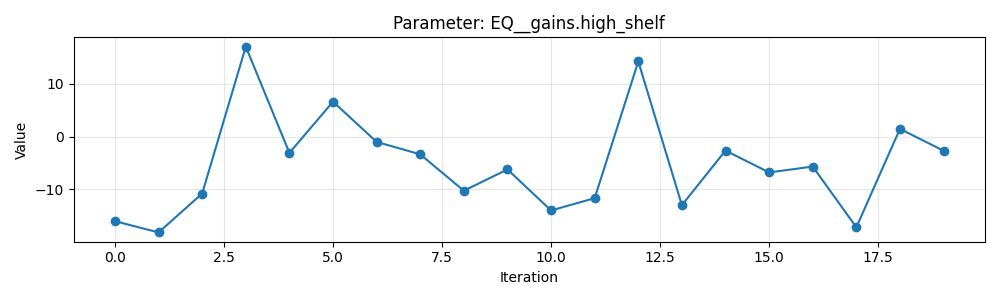

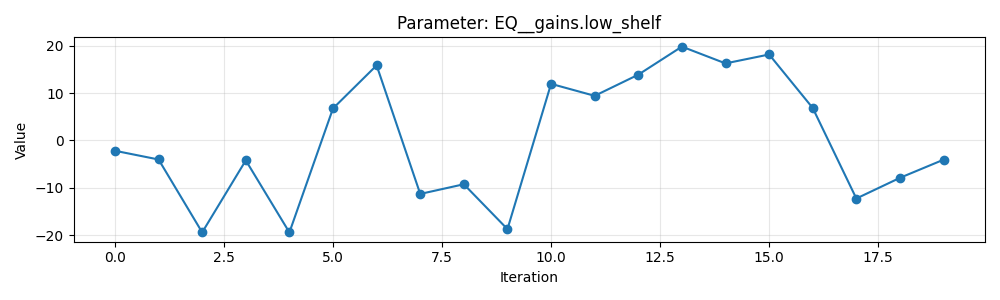

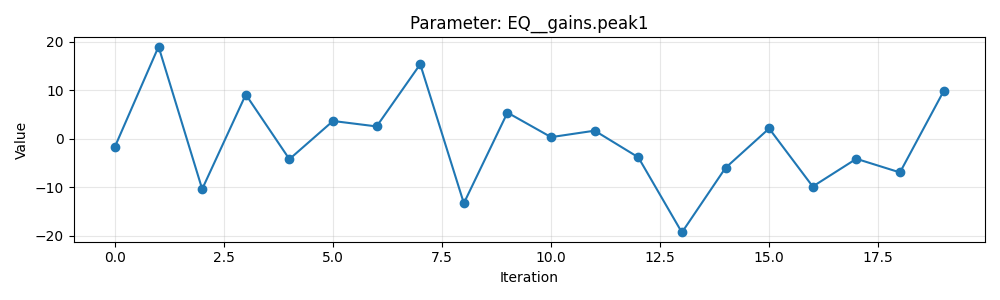

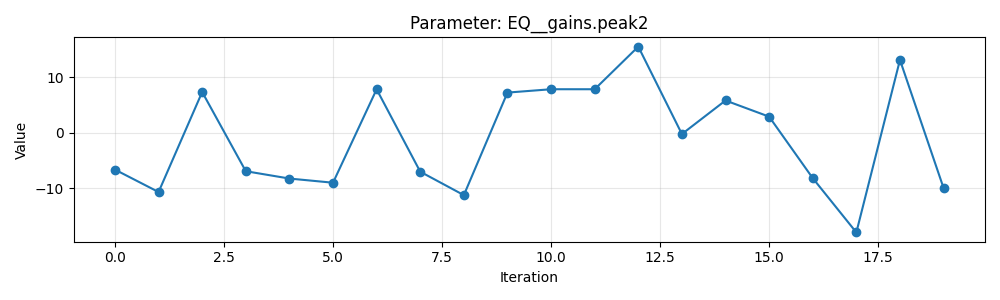

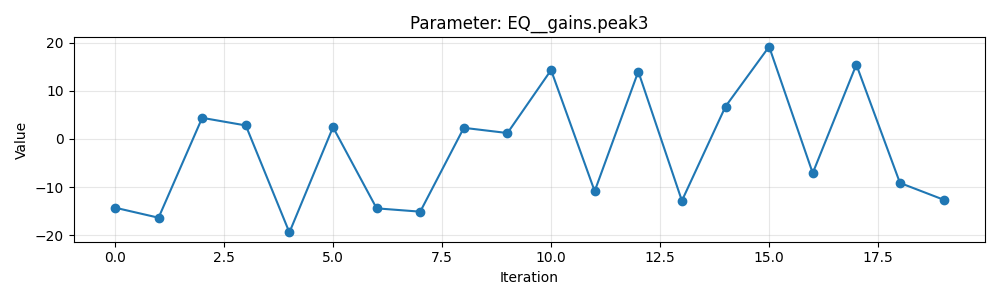

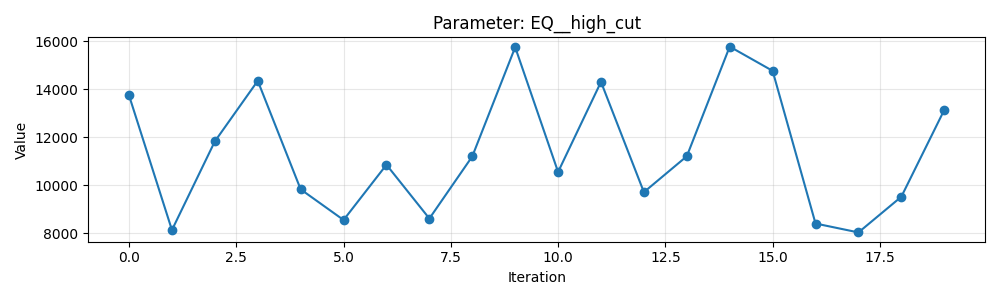

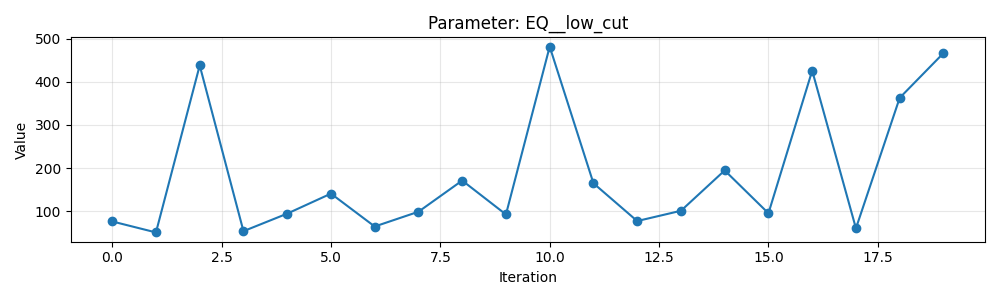

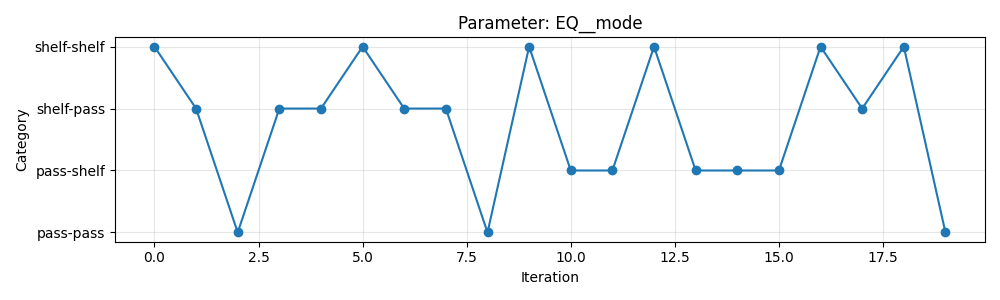

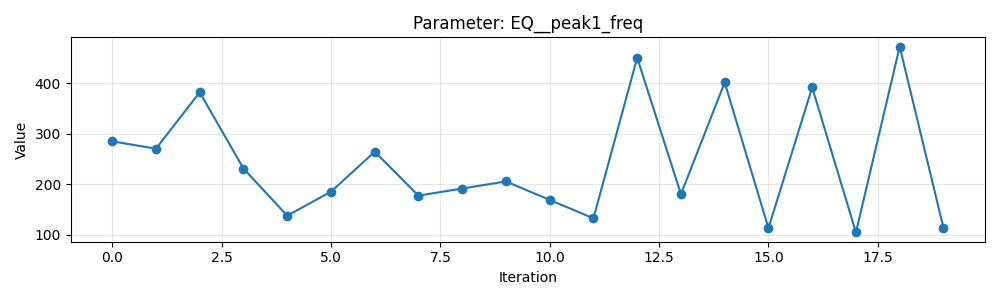

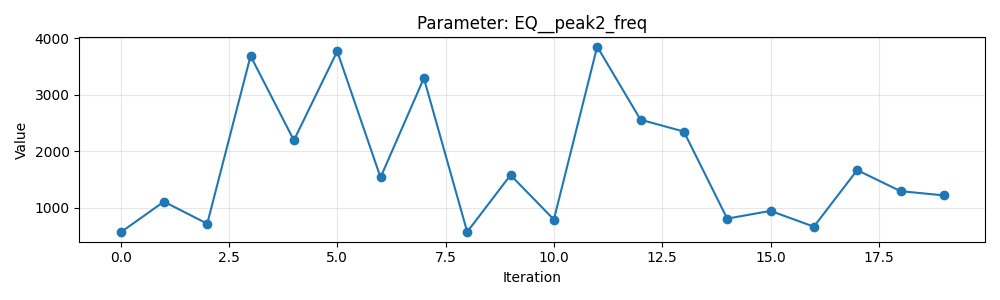

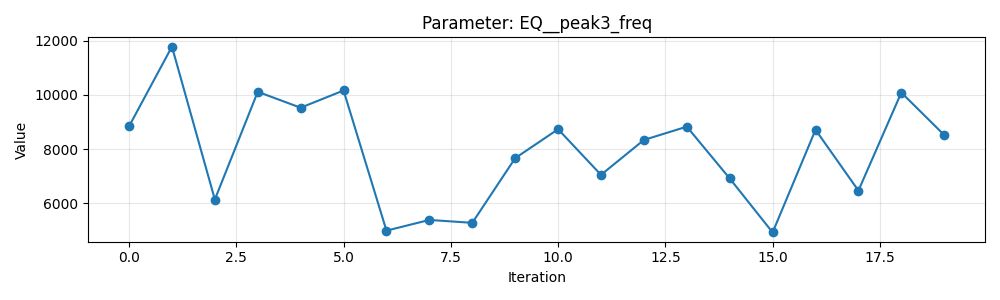

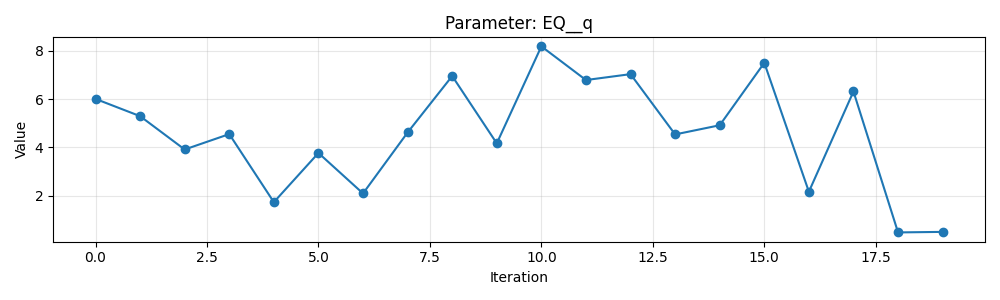

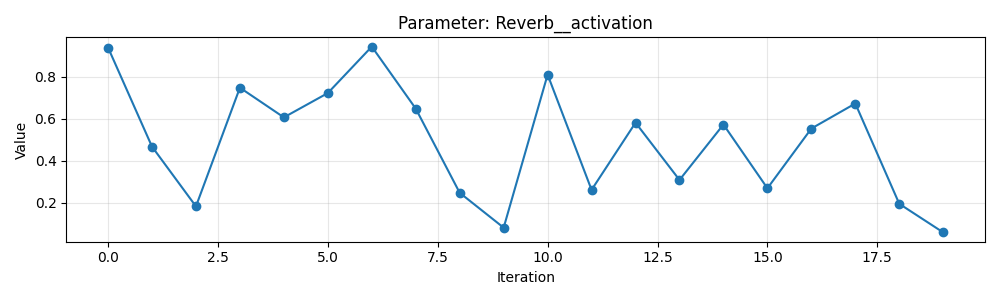

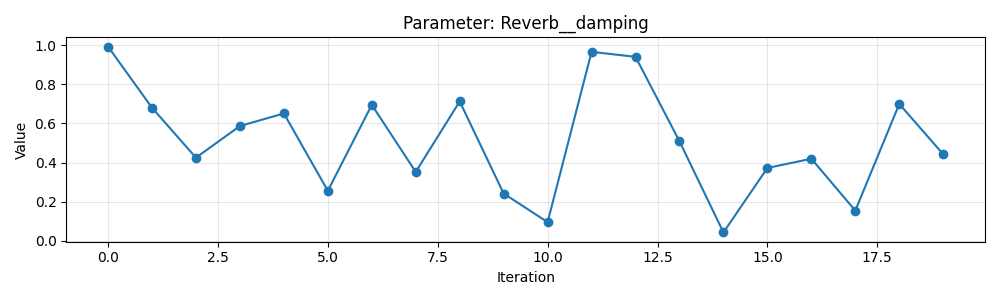

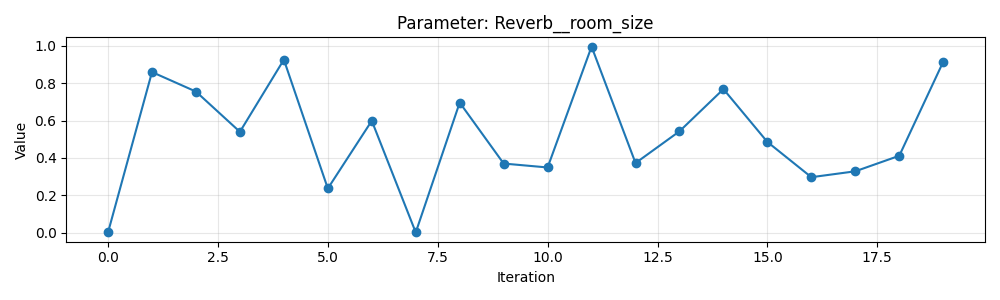

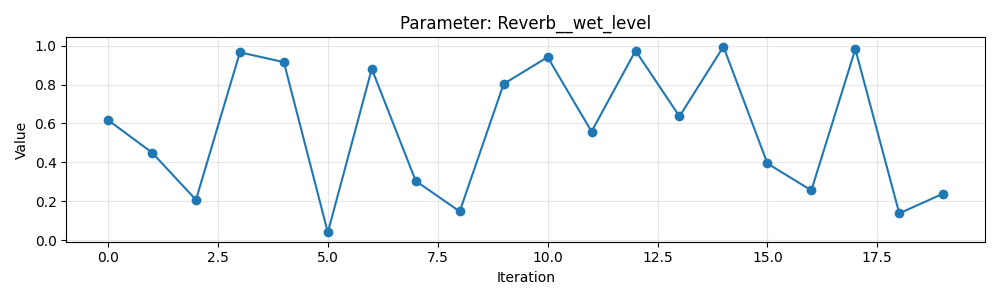


Refinement finished. Total search time: 14.40 seconds
Top 1 configs saved to best_presets.json at ../results/This_sound_is_too_bright__make_it_warmer_20260217_173210.


In [ ]:
from fxsearcher.fxsearcher import fxsearcher, test
fxsearcher(
    audio = '../data/audio/piano.wav',
    prompt=prompt_fxsearcher,
    outdir = "../results",
    top_n = 1,
    n_calls = 20,
    use_guide=True,
    fxs=['EQ', 'Reverb'],
    initial_config=initial_parameters_fxsearcher,
    plot=True
)

## Results

In [22]:
print("🎵 Listen to all versions:\n")

print("0️⃣ Original Audio:")
display(Audio(audio.squeeze().cpu().numpy(), rate=sr))

print(" Processed Audio from LLM initialization:")
display(Audio(audio_llm_initial.squeeze().cpu().numpy(), rate=sr))

print(f"\n1️⃣ Method 1 - Baseline: Direct LLM ('{exp['baseline_prompt']}'):")
display(Audio(audio_baseline.detach().squeeze().cpu().numpy(), rate=sr))

print(f"\n2️⃣ Method 2 - LLM Init + Text2FX (OURS):")
print(f"   Started from: '{INITIAL_PROMPT}'")
print(f"   Refined to: '{exp['text_target']}'")
display(Audio(audio_refined_llm.detach().squeeze().cpu().numpy(), rate=sr))

print("\n3️⃣ Method 3 - Random Init + Text2FX:")
print(f"   Refined to: '{exp['text_target']}'")
display(Audio(audio_refined_random.detach().squeeze().cpu().numpy(), rate=sr))

print(f"\n4️⃣ Method 4 - FxSearcher:")
print(f"   Prompt: '{prompt_fxsearcher}'")
display(Audio(filename='../results/this_sound_is_too_bright__make_it_warmer/best.wav', rate=44100))

🎵 Listen to all versions:


4️⃣ Method 4 - FxSearcher:
   Prompt: 'This sound is too bright, make it warmer'
